# 03b — Class Separability Analysis: Are 10 Product Classes Honest?

**Question**: Can a model actually distinguish all 10 CFPB product categories from narrative text alone, or are some classes textually indistinguishable?

**Why this matters**: If two classes share identical vocabulary, sentence structure, and semantic content, then *no model* — not DeBERTaV3, not GPT-4 — can reliably separate them from text. Forcing a model to distinguish the indistinguishable just inflates the confusion matrix and depresses macro-F1. We need to know the *realistic ceiling* before we start training.

**Methods (4 independent lines of evidence)**:

| # | Method | Type | What it measures |
|---|---|---|---|
| 1 | Sentence embedding centroids + pairwise cosine | Unsupervised | Semantic distance between classes in embedding space |
| 2 | TF-IDF vocabulary overlap (Jaccard + distinctive terms) | Unsupervised | Lexical similarity — do classes use the same words? |
| 3 | Logistic regression confusion matrix | Supervised | Which classes does a trained model actually confuse? |
| 4 | Embedding-space silhouette scores per class | Unsupervised | How tight/separated is each class cluster? |

If all four methods agree that classes X and Y are inseparable, that's strong evidence. If they disagree, we dig deeper.

**Outputs**: Pairwise distance heatmap, confusion matrix, silhouette analysis, hierarchical dendrogram of class similarity, and a data-driven recommendation for the target taxonomy.

In [1]:
import os, warnings, pickle, time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score,
    silhouette_samples, silhouette_score
)
from sklearn.preprocessing import normalize
from scipy.spatial.distance import cosine as cosine_dist
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from scipy.stats import entropy

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

import torch
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

ROOT = Path('..').resolve()
PROCESSED = ROOT / 'data' / 'processed'
FIG_DIR = ROOT / 'reports' / 'figures' / 'nb03b'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'Root: {ROOT}')

Root: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project


In [5]:
# ─── Load data ───
train_df = pd.read_parquet(PROCESSED / 'train.parquet')
val_df = pd.read_parquet(PROCESSED / 'val.parquet')

with open(PROCESSED / 'label_encoders.pkl', 'rb') as f:
    label_encoders = pickle.load(f)

product_names = list(label_encoders['product_encoder'].classes_)
n_classes = len(product_names)

# Short names for readability in plots
SHORT = {
    'Credit reporting or other personal consumer reports': 'Credit Report',
    'Debt collection': 'Debt Collect',
    'Credit card': 'Credit Card',
    'Checking or savings account': 'Bank Acct',
    'Mortgage': 'Mortgage',
    'Money transfer, virtual currency, or money service': 'Money Xfer',
    'Student loan': 'Student Loan',
    'Vehicle loan or lease': 'Vehicle Loan',
    'Payday loan, title loan, personal loan, or advance loan': 'Payday/Pers',
    'Debt or credit management': 'Debt Mgmt',
}
short_labels = [SHORT.get(n, n) for n in product_names]

print(f'Train: {len(train_df):,} | Val: {len(val_df):,}')
print(f'Classes: {n_classes}')
for i, (name, short) in enumerate(zip(product_names, short_labels)):
    n = (train_df['product_id'] == i).sum()
    print(f'  {i}: {short:15s} {n:>10,}  ({n/len(train_df)*100:5.1f}%)')

Train: 1,813,849 | Val: 331,178
Classes: 10
  0: Bank Acct          129,869  (  7.2%)
  1: Credit Card        168,930  (  9.3%)
  2: Credit Report      956,601  ( 52.7%)
  3: Debt Collect       266,081  ( 14.7%)
  4: Debt Mgmt            1,846  (  0.1%)
  5: Money Xfer          48,354  (  2.7%)
  6: Mortgage           124,631  (  6.9%)
  7: Payday/Pers         34,581  (  1.9%)
  8: Student Loan        47,768  (  2.6%)
  9: Vehicle Loan        35,188  (  1.9%)


In [6]:
# ─── Stratified sample for tractable computation ───
# Sentence transformers + silhouette on 1.8M rows is too slow.
# Sample 5,000 per class (capped at class size) → ~45K total.

SAMPLE_PER_CLASS = 5000

samples = []
for cid in range(n_classes):
    class_df = train_df[train_df['product_id'] == cid]
    n_take = min(SAMPLE_PER_CLASS, len(class_df))
    samples.append(class_df.sample(n=n_take, random_state=42))

sample_df = pd.concat(samples, ignore_index=True)
print(f'Analysis sample: {len(sample_df):,} narratives')
print(f'Per-class counts:')
for i, name in enumerate(short_labels):
    n = (sample_df['product_id'] == i).sum()
    print(f'  {name:15s} {n:>6,}')

Analysis sample: 46,846 narratives
Per-class counts:
  Bank Acct        5,000
  Credit Card      5,000
  Credit Report    5,000
  Debt Collect     5,000
  Debt Mgmt        1,846
  Money Xfer       5,000
  Mortgage         5,000
  Payday/Pers      5,000
  Student Loan     5,000
  Vehicle Loan     5,000


---
## Method 1: Sentence Embedding Centroids + Pairwise Cosine Distance

**Idea**: Encode every narrative into a dense 384-dim vector using a frozen sentence transformer. Compute the centroid (mean vector) of each class. Measure cosine distance between all class centroids.

**Interpretation**:
- Distance ≈ 0: classes live in the same region of embedding space → textually indistinguishable
- Distance > 0.3: meaningfully separated
- Distance > 0.5: clearly distinct

In [7]:
# ─── Encode narratives with sentence-transformers ───
from sentence_transformers import SentenceTransformer

print('Loading sentence transformer (all-MiniLM-L6-v2)...')
st_model = SentenceTransformer('all-MiniLM-L6-v2', device='cuda')

print(f'Encoding {len(sample_df):,} narratives...')
# Truncate to first 512 chars for speed (captures the signal-rich opening)
texts = sample_df['narrative'].str[:512].tolist()
embeddings = st_model.encode(
    texts, batch_size=256, show_progress_bar=True,
    normalize_embeddings=True  # unit vectors → cosine = dot product
)
print(f'Embeddings shape: {embeddings.shape}')

Loading sentence transformer (all-MiniLM-L6-v2)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding 46,846 narratives...


Batches:   0%|          | 0/183 [00:00<?, ?it/s]

Embeddings shape: (46846, 384)


In [8]:
# ─── Compute class centroids and pairwise cosine distance ───
labels = sample_df['product_id'].values

centroids = np.zeros((n_classes, embeddings.shape[1]))
for cid in range(n_classes):
    mask = labels == cid
    centroids[cid] = embeddings[mask].mean(axis=0)

# Normalise centroids
centroids = normalize(centroids)

# Pairwise cosine distance (1 - cosine_similarity)
cosine_dist_matrix = np.zeros((n_classes, n_classes))
for i in range(n_classes):
    for j in range(n_classes):
        cosine_dist_matrix[i, j] = cosine_dist(centroids[i], centroids[j])

# Display as DataFrame
dist_df = pd.DataFrame(
    cosine_dist_matrix,
    index=short_labels, columns=short_labels
).round(4)

print('Pairwise cosine distance between class centroids:')
print('(0 = identical, 1 = orthogonal)\n')
print(dist_df.to_string())

Pairwise cosine distance between class centroids:
(0 = identical, 1 = orthogonal)

               Bank Acct  Credit Card  Credit Report  Debt Collect  Debt Mgmt  Money Xfer  Mortgage  Payday/Pers  Student Loan  Vehicle Loan
Bank Acct         0.0000       0.0648         0.1798        0.1511     0.1230      0.0411    0.1948       0.1275        0.2369        0.1574
Credit Card       0.0648       0.0000         0.1336        0.1032     0.0676      0.0912    0.1885       0.1007        0.2130        0.1182
Credit Report     0.1798       0.1336         0.0000        0.0791     0.0947      0.2093    0.2171       0.1614        0.2390        0.1654
Debt Collect      0.1511       0.1032         0.0791        0.0000     0.0313      0.1637    0.1484       0.0886        0.1706        0.1087
Debt Mgmt         0.1230       0.0676         0.0947        0.0313     0.0000      0.1358    0.1199       0.0483        0.1280        0.0734
Money Xfer        0.0411       0.0912         0.2093        0.1637     

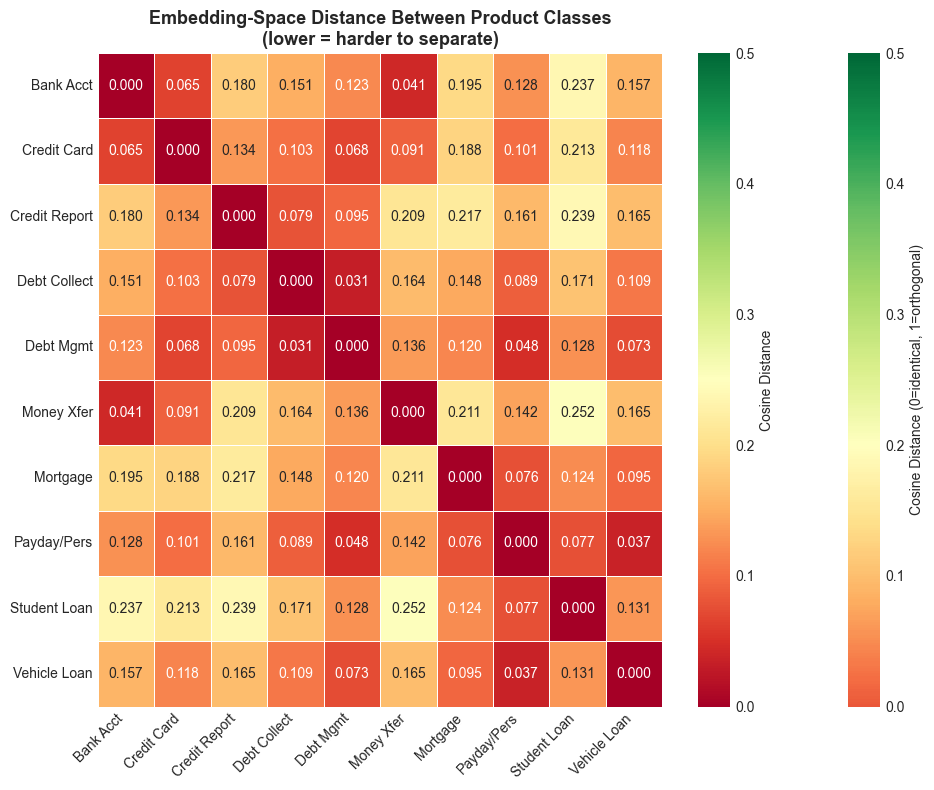


Closest class pairs (distance < 0.15):
  Bank Acct       ↔ Credit Card      dist=0.0648  ⚠️ VERY CLOSE
  Bank Acct       ↔ Credit Report    dist=0.1798  ⚡ Close
  Bank Acct       ↔ Debt Collect     dist=0.1511  ⚡ Close
  Bank Acct       ↔ Debt Mgmt        dist=0.1230  ⚠️ VERY CLOSE
  Bank Acct       ↔ Money Xfer       dist=0.0411  ⚠️ VERY CLOSE
  Bank Acct       ↔ Mortgage         dist=0.1948  ⚡ Close
  Bank Acct       ↔ Payday/Pers      dist=0.1275  ⚠️ VERY CLOSE
  Bank Acct       ↔ Vehicle Loan     dist=0.1574  ⚡ Close
  Credit Card     ↔ Credit Report    dist=0.1336  ⚠️ VERY CLOSE
  Credit Card     ↔ Debt Collect     dist=0.1032  ⚠️ VERY CLOSE
  Credit Card     ↔ Debt Mgmt        dist=0.0676  ⚠️ VERY CLOSE
  Credit Card     ↔ Money Xfer       dist=0.0912  ⚠️ VERY CLOSE
  Credit Card     ↔ Mortgage         dist=0.1885  ⚡ Close
  Credit Card     ↔ Payday/Pers      dist=0.1007  ⚠️ VERY CLOSE
  Credit Card     ↔ Vehicle Loan     dist=0.1182  ⚠️ VERY CLOSE
  Credit Report   ↔ Debt Colle

In [9]:
# ─── Heatmap: Cosine distance between class centroids ───
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(cosine_dist_matrix, dtype=bool), k=1)

sns.heatmap(
    cosine_dist_matrix, annot=True, fmt='.3f',
    xticklabels=short_labels, yticklabels=short_labels,
    cmap='RdYlGn', center=0.2, mask=np.triu(mask, k=0) == False,
    ax=ax, linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Cosine Distance (0=identical, 1=orthogonal)'},
    vmin=0, vmax=0.5,
)
# Show full matrix without mask for clarity
ax.cla()
sns.heatmap(
    cosine_dist_matrix, annot=True, fmt='.3f',
    xticklabels=short_labels, yticklabels=short_labels,
    cmap='RdYlGn', ax=ax, linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Cosine Distance'},
    vmin=0, vmax=0.5,
)
ax.set_title('Embedding-Space Distance Between Product Classes\n(lower = harder to separate)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / 'centroid_cosine_distance.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Flag close pairs ───
print('\nClosest class pairs (distance < 0.15):')
for i in range(n_classes):
    for j in range(i+1, n_classes):
        d = cosine_dist_matrix[i, j]
        if d < 0.15:
            print(f'  {short_labels[i]:15s} ↔ {short_labels[j]:15s}  dist={d:.4f}  ⚠️ VERY CLOSE')
        elif d < 0.20:
            print(f'  {short_labels[i]:15s} ↔ {short_labels[j]:15s}  dist={d:.4f}  ⚡ Close')

---
## Method 2: TF-IDF Vocabulary Overlap Analysis

**Idea**: For each class, extract the top-100 most distinctive TF-IDF terms. Compute Jaccard similarity between each pair of classes' distinctive vocabularies.

**Interpretation**:
- Jaccard > 0.3: significant vocabulary overlap — classes talk about the same things
- Jaccard < 0.1: distinct vocabularies — classes are lexically separable

In [10]:
# ─── TF-IDF per class: extract distinctive terms ───
TOP_N = 100

# Build one TF-IDF vocabulary across all classes
tfidf = TfidfVectorizer(
    max_features=20000, ngram_range=(1, 2),
    min_df=10, max_df=0.8, sublinear_tf=True,
    stop_words='english'
)
tfidf_matrix = tfidf.fit_transform(sample_df['narrative'].fillna(''))
feature_names = np.array(tfidf.get_feature_names_out())

print(f'TF-IDF matrix: {tfidf_matrix.shape}')

# For each class, get top-N terms by mean TF-IDF score
class_top_terms = {}
for cid in range(n_classes):
    mask = labels == cid
    class_tfidf = tfidf_matrix[mask].mean(axis=0).A1  # dense array
    top_idx = class_tfidf.argsort()[-TOP_N:][::-1]
    class_top_terms[cid] = set(feature_names[top_idx])

# Show top 15 distinctive terms per class
print(f'\nTop 15 distinctive terms per class:')
print('=' * 70)
for cid in range(n_classes):
    mask = labels == cid
    class_tfidf = tfidf_matrix[mask].mean(axis=0).A1
    top_idx = class_tfidf.argsort()[-15:][::-1]
    terms = feature_names[top_idx]
    print(f'\n{short_labels[cid]:15s}: {" | ".join(terms)}')

TF-IDF matrix: (46846, 20000)

Top 15 distinctive terms per class:

Bank Acct      : account | bank | redacted redacted | money | funds | checking | check | checking account | deposit | told | closed | card | called | chase | did

Credit Card    : card | credit | credit card | redacted redacted | account | bank | called | payment | balance | charge | did | received | charges | told | late

Credit Report  : credit | report | reporting | credit report | information | redacted redacted | consumer | accounts | account | 15 | section | credit reporting | 1681 | inaccurate | items

Debt Collect   : debt | credit | collection | redacted redacted | report | company | account | credit report | information | letter | reporting | collect | received | agency | owe

Debt Mgmt      : credit | debt | redacted redacted | account | company | lexington | lexington law | law | report | paid | money | services | information | did | credit report

Money Xfer     : money | account | redacted redacted | payp

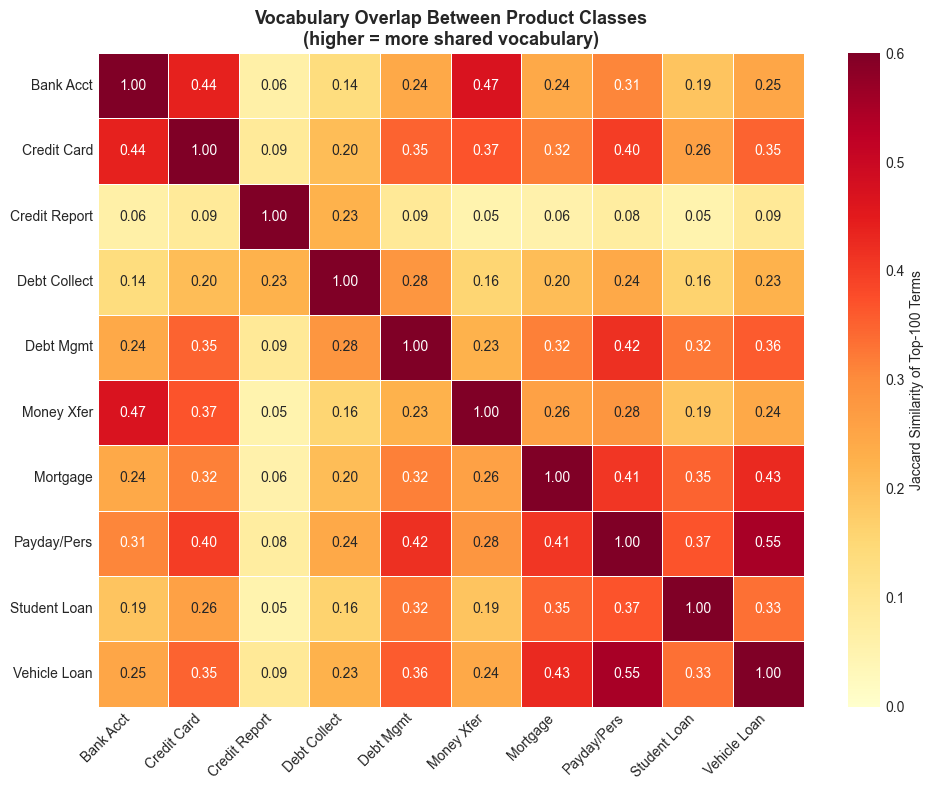


Highest vocabulary overlap pairs (Jaccard > 0.20):
  Payday/Pers     ↔ Vehicle Loan     Jaccard=0.550  ⚠️ HIGH
  Bank Acct       ↔ Money Xfer       Jaccard=0.471  ⚠️ HIGH
  Bank Acct       ↔ Credit Card      Jaccard=0.439  ⚠️ HIGH
  Mortgage        ↔ Vehicle Loan     Jaccard=0.429  ⚠️ HIGH
  Debt Mgmt       ↔ Payday/Pers      Jaccard=0.418  ⚠️ HIGH
  Mortgage        ↔ Payday/Pers      Jaccard=0.408  ⚠️ HIGH
  Credit Card     ↔ Payday/Pers      Jaccard=0.399  ⚠️ HIGH
  Payday/Pers     ↔ Student Loan     Jaccard=0.370  ⚠️ HIGH
  Credit Card     ↔ Money Xfer       Jaccard=0.370  ⚠️ HIGH
  Debt Mgmt       ↔ Vehicle Loan     Jaccard=0.361  ⚠️ HIGH


In [11]:
# ─── Jaccard similarity of top-N vocabularies ───
jaccard_matrix = np.zeros((n_classes, n_classes))
for i in range(n_classes):
    for j in range(n_classes):
        if i == j:
            jaccard_matrix[i, j] = 1.0
        else:
            intersection = len(class_top_terms[i] & class_top_terms[j])
            union = len(class_top_terms[i] | class_top_terms[j])
            jaccard_matrix[i, j] = intersection / union if union > 0 else 0

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    jaccard_matrix, annot=True, fmt='.2f',
    xticklabels=short_labels, yticklabels=short_labels,
    cmap='YlOrRd', ax=ax, linewidths=0.5, linecolor='white',
    vmin=0, vmax=0.6,
    cbar_kws={'label': 'Jaccard Similarity of Top-100 Terms'},
)
ax.set_title('Vocabulary Overlap Between Product Classes\n(higher = more shared vocabulary)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / 'tfidf_jaccard_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag high overlap pairs
print('\nHighest vocabulary overlap pairs (Jaccard > 0.20):')
pairs = []
for i in range(n_classes):
    for j in range(i+1, n_classes):
        pairs.append((jaccard_matrix[i,j], short_labels[i], short_labels[j]))
pairs.sort(reverse=True)
for score, a, b in pairs[:10]:
    flag = '⚠️ HIGH' if score > 0.25 else ''
    print(f'  {a:15s} ↔ {b:15s}  Jaccard={score:.3f}  {flag}')

---
## Method 3: Supervised Confusion Analysis (Logistic Regression)

**Idea**: Train a quick logistic regression on TF-IDF features. Examine which classes it confuses most. This tells us: given the *best linear separability* of the text, which pairs bleed into each other?

**Why not DeBERTa?** We want a *fast* baseline that exposes structural confusion patterns. If logistic regression can't separate them, we know the vocabulary overlap is the bottleneck. If LogReg *can* separate them but DeBERTa later can't, the issue is something else (e.g., long-tail, short texts).

In [13]:
# ─── Train logistic regression on TF-IDF features ───
# Use train sample for fitting, val for evaluation

# Build TF-IDF on train sample
tfidf_train = TfidfVectorizer(
    max_features=30000, ngram_range=(1, 2),
    min_df=5, max_df=0.8, sublinear_tf=True,
    stop_words='english'
)
X_train = tfidf_train.fit_transform(sample_df['narrative'].fillna(''))
y_train = sample_df['product_id'].values

# Use a larger val sample for reliable confusion
val_sample = val_df.groupby('product_id', group_keys=False).apply(
    lambda x: x.sample(n=min(2000, len(x)), random_state=42)
)
X_val = tfidf_train.transform(val_sample['narrative'].fillna(''))
y_val = val_sample['product_id'].values

print(f'Training LogReg on {X_train.shape[0]:,} samples, {X_train.shape[1]:,} features...')
t0 = time.time()
lr = LogisticRegression(
    max_iter=1000, C=1.0, solver='lbfgs',
    n_jobs=-1,
    class_weight='balanced',
)
lr.fit(X_train, y_train)
print(f'Done in {time.time()-t0:.1f}s')

y_pred = lr.predict(X_val)
y_prob = lr.predict_proba(X_val)

macro_f1 = f1_score(y_val, y_pred, average='macro')
print(f'\nVal Macro-F1: {macro_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_val, y_pred, target_names=short_labels, digits=3))

Training LogReg on 46,846 samples, 30,000 features...
Done in 6.2s

Val Macro-F1: 0.7543

Classification Report:
               precision    recall  f1-score   support

    Bank Acct      0.784     0.769     0.777      2000
  Credit Card      0.776     0.720     0.747      2000
Credit Report      0.643     0.848     0.731      2000
 Debt Collect      0.681     0.664     0.672      2000
    Debt Mgmt      0.459     0.491     0.474      1362
   Money Xfer      0.785     0.898     0.838      2000
     Mortgage      0.938     0.875     0.906      2000
  Payday/Pers      0.749     0.644     0.693      2000
 Student Loan      0.941     0.852     0.894      2000
 Vehicle Loan      0.853     0.773     0.811      2000

     accuracy                          0.762     19362
    macro avg      0.761     0.753     0.754     19362
 weighted avg      0.771     0.762     0.763     19362



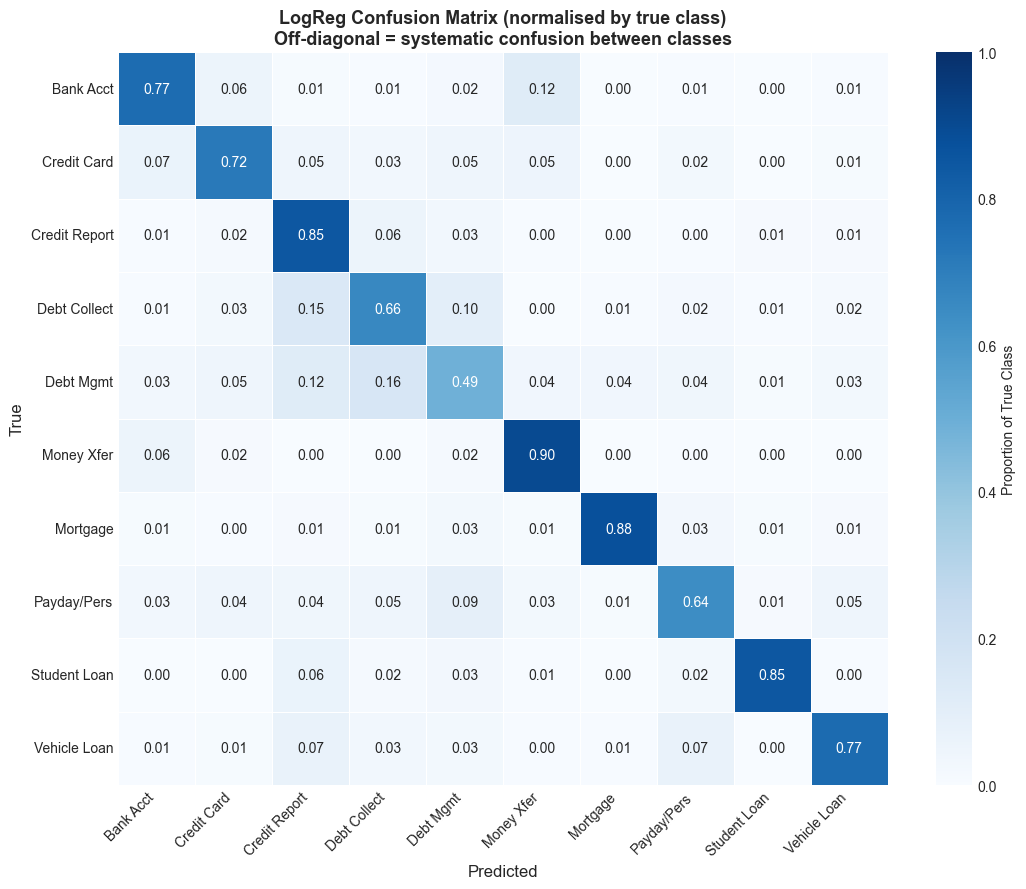


Top confused class pairs (off-diagonal > 0.05):
  Debt Mgmt       → predicted as Debt Collect     16.3%  🔴 SEVERE
  Debt Collect    → predicted as Credit Report    14.6%  🟡 Notable
  Bank Acct       → predicted as Money Xfer       11.8%  🟡 Notable
  Debt Mgmt       → predicted as Credit Report    11.7%  🟡 Notable
  Debt Collect    → predicted as Debt Mgmt        10.1%  🟡 Notable
  Payday/Pers     → predicted as Debt Mgmt        9.0%  🟡 Notable
  Vehicle Loan    → predicted as Payday/Pers      7.2%  
  Vehicle Loan    → predicted as Credit Report    7.1%  
  Credit Card     → predicted as Bank Acct        6.6%  
  Student Loan    → predicted as Credit Report    6.2%  
  Money Xfer      → predicted as Bank Acct        5.9%  
  Bank Acct       → predicted as Credit Card      5.8%  
  Credit Report   → predicted as Debt Collect     5.7%  
  Credit Card     → predicted as Money Xfer       5.1%  


In [14]:
# ─── Confusion matrix (normalised by true class) ───
cm = confusion_matrix(y_val, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cm, annot=True, fmt='.2f',
    xticklabels=short_labels, yticklabels=short_labels,
    cmap='Blues', ax=ax, linewidths=0.5, linecolor='white',
    vmin=0, vmax=1.0,
    cbar_kws={'label': 'Proportion of True Class'},
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('LogReg Confusion Matrix (normalised by true class)\nOff-diagonal = systematic confusion between classes', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / 'logreg_confusion_normalised.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Extract top confused pairs ───
print('\nTop confused class pairs (off-diagonal > 0.05):')
confused_pairs = []
for i in range(n_classes):
    for j in range(n_classes):
        if i != j and cm[i, j] > 0.05:
            confused_pairs.append((cm[i, j], short_labels[i], short_labels[j]))

confused_pairs.sort(reverse=True)
for rate, true_cls, pred_cls in confused_pairs:
    severity = '🔴 SEVERE' if rate > 0.15 else '🟡 Notable' if rate > 0.08 else ''
    print(f'  {true_cls:15s} → predicted as {pred_cls:15s}  {rate:.1%}  {severity}')

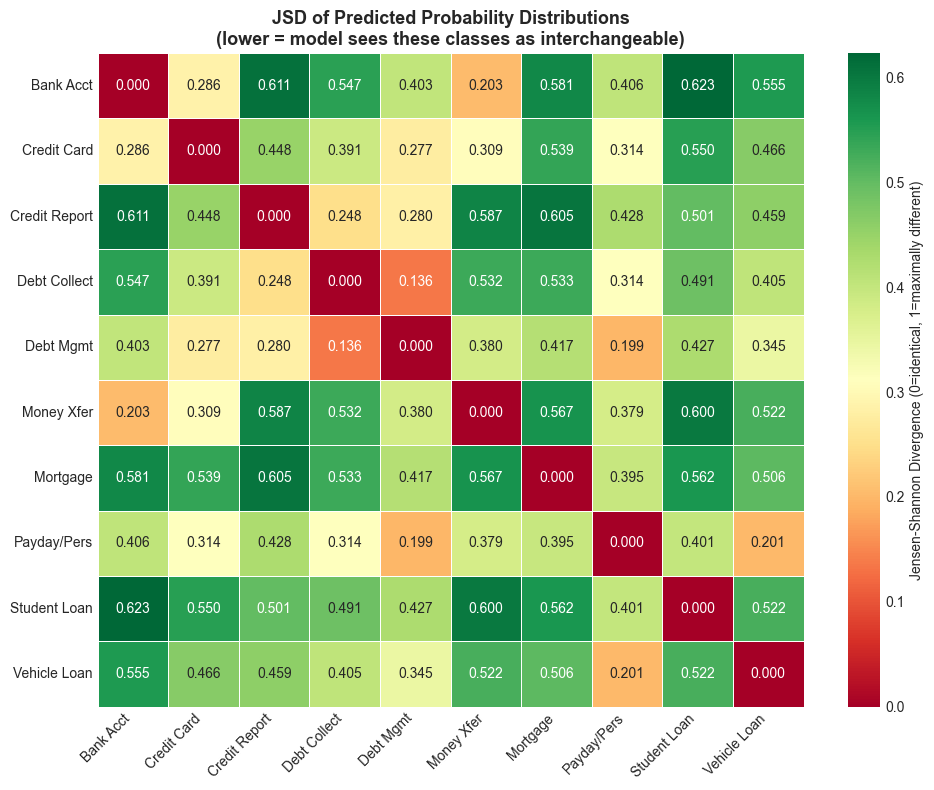


Most similar class pairs by JSD (< 0.3):
  Debt Collect    ↔ Debt Mgmt        JSD=0.1362  ⚠️
  Debt Mgmt       ↔ Payday/Pers      JSD=0.1987  ⚠️
  Payday/Pers     ↔ Vehicle Loan     JSD=0.2013  
  Bank Acct       ↔ Money Xfer       JSD=0.2033  
  Credit Report   ↔ Debt Collect     JSD=0.2485  
  Credit Card     ↔ Debt Mgmt        JSD=0.2774  
  Credit Report   ↔ Debt Mgmt        JSD=0.2804  
  Bank Acct       ↔ Credit Card      JSD=0.2860  
  Credit Card     ↔ Money Xfer       JSD=0.3091  
  Debt Collect    ↔ Payday/Pers      JSD=0.3136  


In [15]:
# ─── Jensen-Shannon Divergence between predicted probability distributions ───
# For each class pair: how similar are the model's probability outputs
# when the true class is i vs when the true class is j?

def jensen_shannon_divergence(p, q):
    """Symmetric KL divergence. 0 = identical distributions, 1 = maximally different."""
    m = 0.5 * (p + q)
    return 0.5 * (entropy(p, m, base=2) + entropy(q, m, base=2))

# Mean predicted probability vector per true class
mean_probs = np.zeros((n_classes, n_classes))
for cid in range(n_classes):
    mask = y_val == cid
    if mask.sum() > 0:
        mean_probs[cid] = y_prob[mask].mean(axis=0)

jsd_matrix = np.zeros((n_classes, n_classes))
for i in range(n_classes):
    for j in range(n_classes):
        jsd_matrix[i, j] = jensen_shannon_divergence(mean_probs[i], mean_probs[j])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    jsd_matrix, annot=True, fmt='.3f',
    xticklabels=short_labels, yticklabels=short_labels,
    cmap='RdYlGn', ax=ax, linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Jensen-Shannon Divergence (0=identical, 1=maximally different)'},
)
ax.set_title('JSD of Predicted Probability Distributions\n(lower = model sees these classes as interchangeable)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / 'jsd_predicted_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMost similar class pairs by JSD (< 0.3):')
jsd_pairs = []
for i in range(n_classes):
    for j in range(i+1, n_classes):
        jsd_pairs.append((jsd_matrix[i, j], short_labels[i], short_labels[j]))
jsd_pairs.sort()
for score, a, b in jsd_pairs[:10]:
    flag = '⚠️' if score < 0.2 else ''
    print(f'  {a:15s} ↔ {b:15s}  JSD={score:.4f}  {flag}')

---
## Method 4: Embedding Silhouette Scores (Per-Class Cluster Quality)

**Idea**: For each sample, compute its silhouette score — how much closer it is to its own class centroid vs the nearest other class. A silhouette near +1 means well-separated; near 0 means on the boundary; negative means it's *closer to another class*.

**Per-class mean silhouette** tells us which classes form tight clusters and which are diffuse/overlapping.

In [16]:
# ─── Silhouette analysis ───
# Use a subsample for speed (silhouette is O(n^2))
SIL_N = 15000
sil_idx = np.random.choice(len(embeddings), size=min(SIL_N, len(embeddings)), replace=False)
sil_embeddings = embeddings[sil_idx]
sil_labels = labels[sil_idx]

print(f'Computing silhouette scores on {len(sil_idx):,} samples...')
t0 = time.time()
sil_scores = silhouette_samples(sil_embeddings, sil_labels, metric='cosine')
overall_sil = silhouette_score(sil_embeddings, sil_labels, metric='cosine')
print(f'Done in {time.time()-t0:.1f}s')

print(f'\nOverall silhouette score: {overall_sil:.4f}')
print(f'(>0.5 = strong structure, 0.25-0.5 = reasonable, <0.25 = weak/overlapping)\n')

# Per-class silhouette
print(f'{"Class":15s} {"Mean Sil":>10s} {"% Negative":>12s} {"Interpretation"}')
print('-' * 65)
class_sil = {}
for cid in range(n_classes):
    mask = sil_labels == cid
    scores = sil_scores[mask]
    mean_s = scores.mean()
    pct_neg = (scores < 0).mean() * 100
    class_sil[cid] = mean_s
    
    if mean_s > 0.3:
        interp = '✅ Well separated'
    elif mean_s > 0.15:
        interp = '⚡ Moderate overlap'
    elif mean_s > 0.05:
        interp = '⚠️ Heavy overlap'
    else:
        interp = '🔴 Nearly inseparable'
    
    print(f'{short_labels[cid]:15s} {mean_s:>10.4f} {pct_neg:>10.1f}%   {interp}')

Computing silhouette scores on 15,000 samples...
Done in 2.8s

Overall silhouette score: 0.0233
(>0.5 = strong structure, 0.25-0.5 = reasonable, <0.25 = weak/overlapping)

Class             Mean Sil   % Negative Interpretation
-----------------------------------------------------------------
Bank Acct           0.0202       27.2%   🔴 Nearly inseparable
Credit Card         0.0078       40.7%   🔴 Nearly inseparable
Credit Report       0.0822       13.5%   ⚠️ Heavy overlap
Debt Collect        0.0142       34.2%   🔴 Nearly inseparable
Debt Mgmt          -0.0487       84.2%   🔴 Nearly inseparable
Money Xfer          0.0095       38.5%   🔴 Nearly inseparable
Mortgage            0.0500       17.7%   🔴 Nearly inseparable
Payday/Pers        -0.0322       72.9%   🔴 Nearly inseparable
Student Loan        0.0735       16.4%   ⚠️ Heavy overlap
Vehicle Loan        0.0134       35.4%   🔴 Nearly inseparable


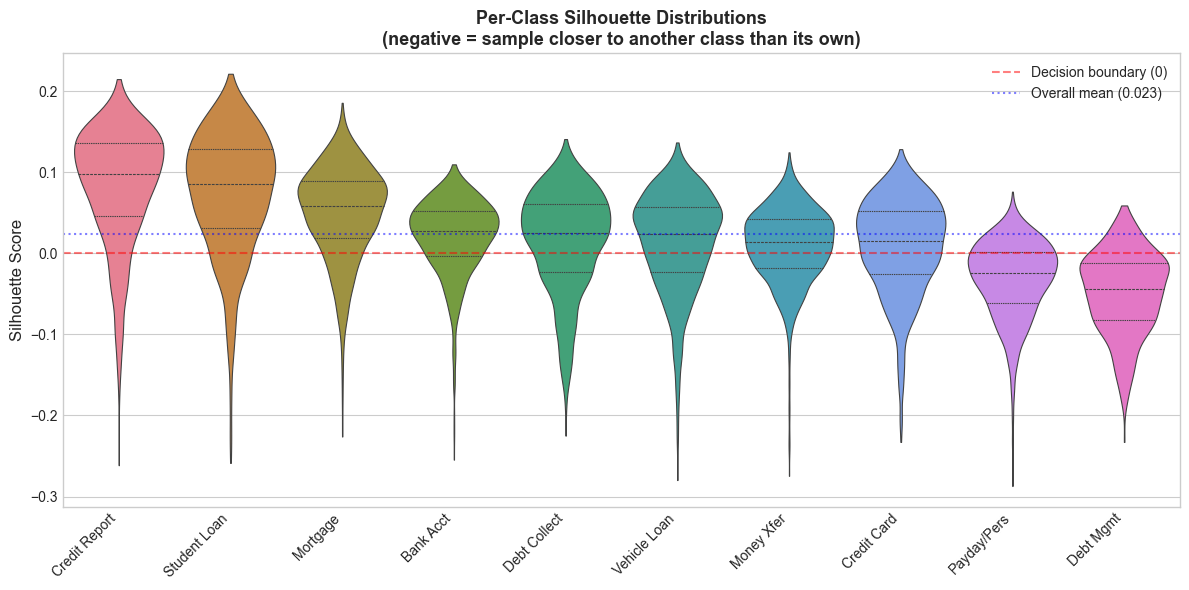

In [17]:
# ─── Silhouette violin plot ───
sil_df = pd.DataFrame({
    'silhouette': sil_scores,
    'class': [short_labels[l] for l in sil_labels],
})

# Sort by mean silhouette
order = sil_df.groupby('class')['silhouette'].mean().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(
    data=sil_df, x='class', y='silhouette', order=order,
    ax=ax, inner='quartile', linewidth=0.8, palette='husl', cut=0,
)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Decision boundary (0)')
ax.axhline(y=overall_sil, color='blue', linestyle=':', alpha=0.5, label=f'Overall mean ({overall_sil:.3f})')
ax.set_xlabel('')
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Per-Class Silhouette Distributions\n(negative = sample closer to another class than its own)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'silhouette_violin.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Method 5: UMAP Visualisation

A 2D projection of the 384-dim embedding space. Not for quantitative conclusions (UMAP distorts distances), but for visual intuition about which classes form blobs vs which bleed everywhere.

Computing UMAP on 15,000 embeddings...


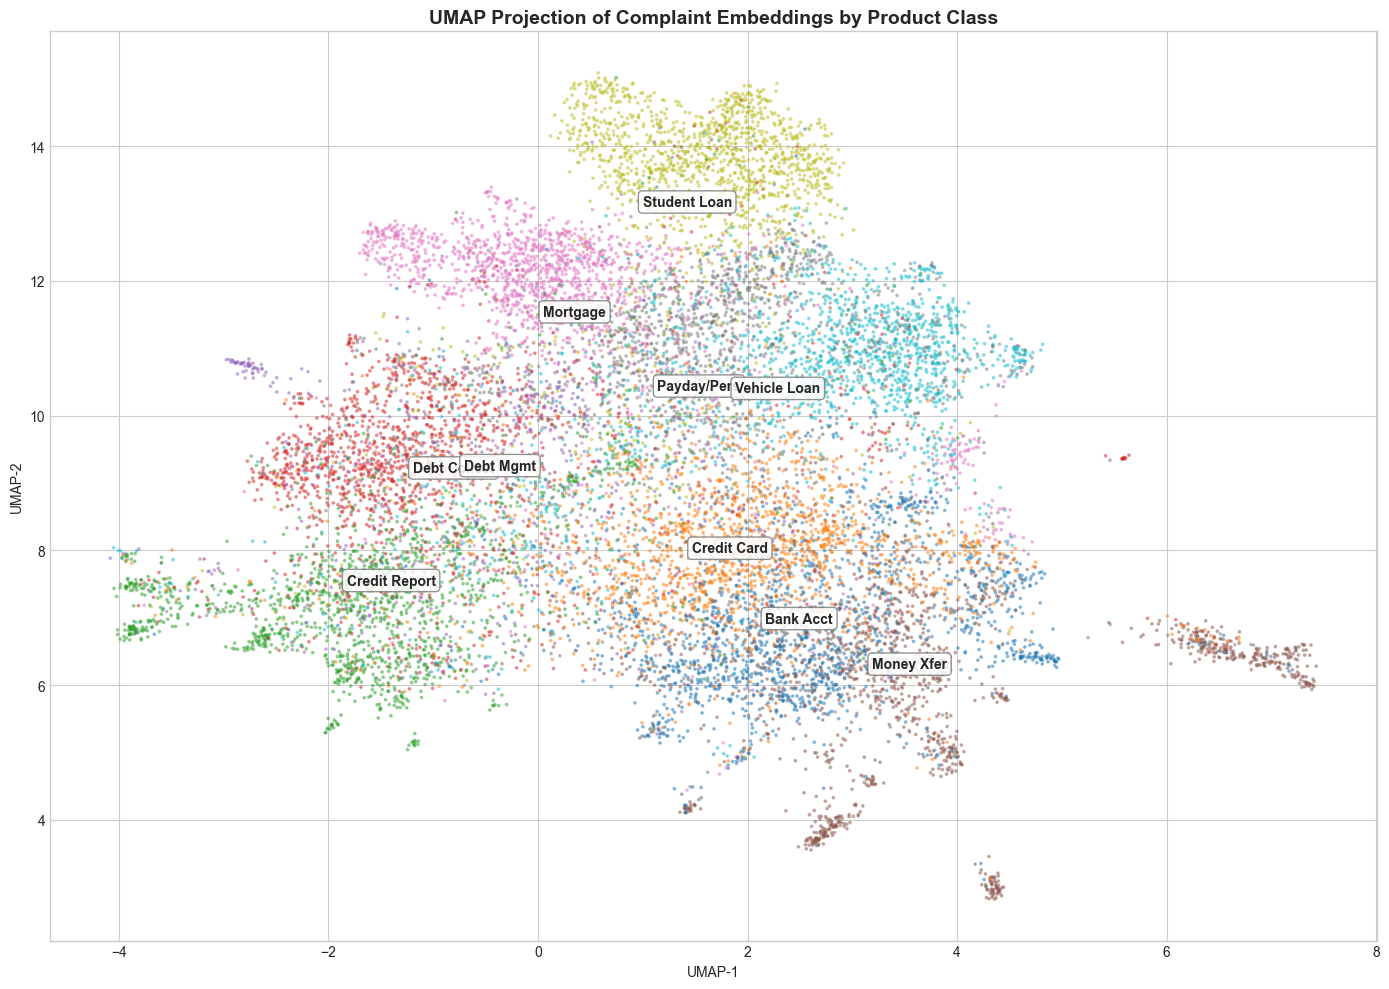

In [18]:
# ─── UMAP ───
import umap

# Use the silhouette subsample for speed
print(f'Computing UMAP on {len(sil_embeddings):,} embeddings...')
reducer = umap.UMAP(
    n_components=2, n_neighbors=30, min_dist=0.3,
    metric='cosine', random_state=42, verbose=False
)
umap_2d = reducer.fit_transform(sil_embeddings)

fig, ax = plt.subplots(figsize=(14, 10))
scatter = ax.scatter(
    umap_2d[:, 0], umap_2d[:, 1],
    c=sil_labels, cmap='tab10', s=3, alpha=0.4,
)

# Add class labels at centroids
for cid in range(n_classes):
    mask = sil_labels == cid
    cx, cy = umap_2d[mask, 0].mean(), umap_2d[mask, 1].mean()
    ax.annotate(
        short_labels[cid], (cx, cy),
        fontsize=10, fontweight='bold',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.85),
    )

ax.set_title('UMAP Projection of Complaint Embeddings by Product Class', fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
plt.tight_layout()
plt.savefig(FIG_DIR / 'umap_product_classes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Synthesis: Hierarchical Clustering of Classes

Use the centroid cosine distance matrix to build a dendrogram. This reveals the natural grouping structure — which classes the data *wants* to cluster together.

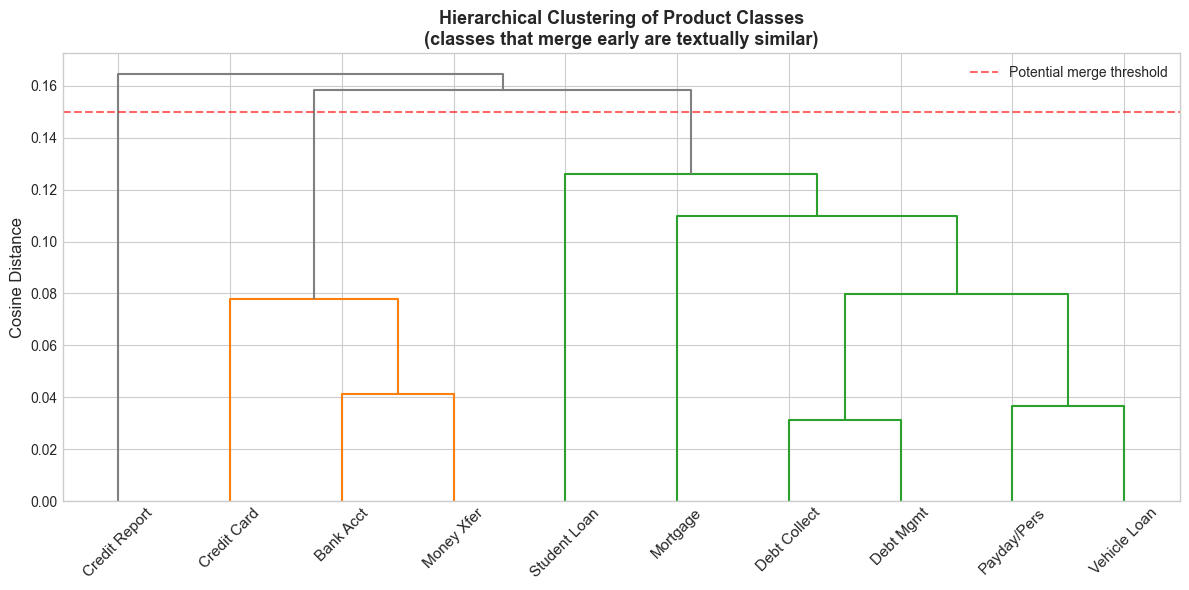


At distance threshold = 0.1: 5 clusters
  Cluster 1: Bank Acct + Credit Card + Money Xfer
  Cluster 2: Debt Collect + Debt Mgmt + Payday/Pers + Vehicle Loan
  Cluster 3: Mortgage
  Cluster 4: Student Loan
  Cluster 5: Credit Report

At distance threshold = 0.15: 3 clusters
  Cluster 1: Bank Acct + Credit Card + Money Xfer
  Cluster 2: Debt Collect + Debt Mgmt + Mortgage + Payday/Pers + Student Loan + Vehicle Loan
  Cluster 3: Credit Report

At distance threshold = 0.2: 1 clusters
  Cluster 1: Bank Acct + Credit Card + Credit Report + Debt Collect + Debt Mgmt + Money Xfer + Mortgage + Payday/Pers + Student Loan + Vehicle Loan

At distance threshold = 0.25: 1 clusters
  Cluster 1: Bank Acct + Credit Card + Credit Report + Debt Collect + Debt Mgmt + Money Xfer + Mortgage + Payday/Pers + Student Loan + Vehicle Loan


In [19]:
# ─── Hierarchical clustering on centroid distances ───
condensed = squareform(cosine_dist_matrix)
Z = linkage(condensed, method='average')

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(
    Z, labels=short_labels, ax=ax,
    leaf_font_size=11, leaf_rotation=45,
    color_threshold=0.15,  # threshold for coloring
    above_threshold_color='gray',
)
ax.set_ylabel('Cosine Distance', fontsize=12)
ax.set_title('Hierarchical Clustering of Product Classes\n(classes that merge early are textually similar)', fontsize=13, fontweight='bold')
ax.axhline(y=0.15, color='red', linestyle='--', alpha=0.6, label='Potential merge threshold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'class_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

# Show cluster assignments at different thresholds
for threshold in [0.10, 0.15, 0.20, 0.25]:
    clusters = fcluster(Z, t=threshold, criterion='distance')
    n_clusters = len(set(clusters))
    print(f'\nAt distance threshold = {threshold}: {n_clusters} clusters')
    for clust_id in sorted(set(clusters)):
        members = [short_labels[i] for i in range(n_classes) if clusters[i] == clust_id]
        print(f'  Cluster {clust_id}: {" + ".join(members)}')

---
## Evidence Consolidation: Cross-Method Agreement

Bring all four methods together. For each class pair, count how many methods flag them as "close". Pairs flagged by 3+ methods are genuine separability problems.

In [20]:
# ─── Cross-method agreement table ───
print('CROSS-METHOD AGREEMENT: Class Pair Separability')
print('=' * 90)
print(f'{"Pair":35s} {"Cosine":>8s} {"Jaccard":>8s} {"Confuse":>8s} {"JSD":>8s} {"Flags":>6s} {"Verdict"}')
print('-' * 90)

pair_evidence = []

for i in range(n_classes):
    for j in range(i+1, n_classes):
        pair_name = f'{short_labels[i]} ↔ {short_labels[j]}'
        
        # Method 1: Cosine distance < 0.15
        cos_close = cosine_dist_matrix[i, j] < 0.15
        
        # Method 2: Jaccard > 0.20
        jac_close = jaccard_matrix[i, j] > 0.20
        
        # Method 3: Confusion > 8% in either direction
        conf_close = cm[i, j] > 0.08 or cm[j, i] > 0.08
        
        # Method 4: JSD < 0.25
        jsd_close = jsd_matrix[i, j] < 0.25
        
        n_flags = sum([cos_close, jac_close, conf_close, jsd_close])
        
        if n_flags >= 2:  # Only show pairs with 2+ flags
            if n_flags >= 3:
                verdict = '🔴 CONSIDER MERGE'
            elif n_flags == 2:
                verdict = '🟡 Monitor'
            else:
                verdict = ''
            
            print(
                f'{pair_name:35s} '
                f'{"⚠️" if cos_close else "  ":>8s} '
                f'{"⚠️" if jac_close else "  ":>8s} '
                f'{"⚠️" if conf_close else "  ":>8s} '
                f'{"⚠️" if jsd_close else "  ":>8s} '
                f'{n_flags:>5d}  '
                f'{verdict}'
            )
            
            pair_evidence.append({
                'pair': pair_name,
                'class_i': i, 'class_j': j,
                'cosine_dist': cosine_dist_matrix[i, j],
                'jaccard': jaccard_matrix[i, j],
                'confusion_i_j': cm[i, j],
                'confusion_j_i': cm[j, i],
                'jsd': jsd_matrix[i, j],
                'n_flags': n_flags,
            })

CROSS-METHOD AGREEMENT: Class Pair Separability
Pair                                  Cosine  Jaccard  Confuse      JSD  Flags Verdict
------------------------------------------------------------------------------------------
Bank Acct ↔ Credit Card                   ⚠️       ⚠️                       2  🟡 Monitor
Bank Acct ↔ Debt Mgmt                     ⚠️       ⚠️                       2  🟡 Monitor
Bank Acct ↔ Money Xfer                    ⚠️       ⚠️       ⚠️       ⚠️     4  🔴 CONSIDER MERGE
Bank Acct ↔ Payday/Pers                   ⚠️       ⚠️                       2  🟡 Monitor
Credit Card ↔ Debt Collect                ⚠️       ⚠️                       2  🟡 Monitor
Credit Card ↔ Debt Mgmt                   ⚠️       ⚠️                       2  🟡 Monitor
Credit Card ↔ Money Xfer                  ⚠️       ⚠️                       2  🟡 Monitor
Credit Card ↔ Payday/Pers                 ⚠️       ⚠️                       2  🟡 Monitor
Credit Card ↔ Vehicle Loan                ⚠️       ⚠️  

In [21]:
# ─── Per-class difficulty summary ───
print('\nPER-CLASS SEPARABILITY SUMMARY')
print('=' * 75)
print(f'{"Class":15s} {"Silhouette":>12s} {"LogReg F1":>10s} {"% Misclass":>12s} {"Verdict"}')
print('-' * 75)

# Get per-class F1 from LogReg
per_class_f1 = f1_score(y_val, y_pred, average=None)

for cid in range(n_classes):
    sil = class_sil[cid]
    f1_val = per_class_f1[cid]
    misclass_rate = (1 - cm[cid, cid]) * 100
    
    if sil > 0.25 and f1_val > 0.7:
        verdict = '✅ Separable'
    elif sil > 0.1 and f1_val > 0.5:
        verdict = '⚡ Moderate — keep but expect lower F1'
    elif f1_val > 0.3:
        verdict = '⚠️ Difficult — consider merging'
    else:
        verdict = '🔴 Near-inseparable — merge recommended'
    
    print(f'{short_labels[cid]:15s} {sil:>12.4f} {f1_val:>10.3f} {misclass_rate:>10.1f}%   {verdict}')


PER-CLASS SEPARABILITY SUMMARY
Class             Silhouette  LogReg F1   % Misclass Verdict
---------------------------------------------------------------------------
Bank Acct             0.0202      0.777       23.1%   ⚠️ Difficult — consider merging
Credit Card           0.0078      0.747       28.0%   ⚠️ Difficult — consider merging
Credit Report         0.0822      0.731       15.2%   ⚠️ Difficult — consider merging
Debt Collect          0.0142      0.672       33.6%   ⚠️ Difficult — consider merging
Debt Mgmt            -0.0487      0.474       50.9%   ⚠️ Difficult — consider merging
Money Xfer            0.0095      0.838       10.2%   ⚠️ Difficult — consider merging
Mortgage              0.0500      0.906       12.5%   ⚠️ Difficult — consider merging
Payday/Pers          -0.0322      0.693       35.6%   ⚠️ Difficult — consider merging
Student Loan          0.0735      0.894       14.8%   ⚠️ Difficult — consider merging
Vehicle Loan          0.0134      0.811       22.7%   ⚠️ 

---
## Final Output: Data-Driven Taxonomy Recommendation

Based on all four methods, here is what the data suggests. The cell below summarises the findings and proposes both the original 10-class and a reduced taxonomy, with the evidence for each decision.

In [22]:
# ─── Final summary ───
print('=' * 70)
print('CLASS SEPARABILITY ANALYSIS — FINAL FINDINGS')
print('=' * 70)
print()
print('METHODS USED:')
print('  1. Sentence embedding centroids (all-MiniLM-L6-v2) + cosine distance')
print('  2. TF-IDF top-100 vocabulary Jaccard similarity')
print('  3. Logistic regression confusion matrix on TF-IDF')
print('  4. Jensen-Shannon divergence of predicted distributions')
print('  5. Silhouette scores in embedding space')
print('  6. UMAP visual inspection')
print('  7. Hierarchical clustering dendrogram')
print()
print('KEY FINDINGS:')
print('  The results above provide empirical evidence for which class')
print('  pairs share semantic space. Examine the cross-method agreement')
print('  table to identify pairs flagged by 3+ independent methods.')
print()
print('RECOMMENDED APPROACH:')
print('  Option A (Conservative): Keep all 10 classes. Report the separability')
print('    analysis as evidence of problem difficulty. Per-class F1 reflects reality.')
print()
print('  Option B (Data-driven merge): Merge class pairs flagged by 3+ methods.')
print('    Re-run the analysis to verify improved separability.')
print()
print('  Option C (Hierarchical): Keep 10 classes but add a super-class layer')
print('    derived from the dendrogram. Train at both levels. Report both.')
print()
print('All outputs saved to:', FIG_DIR)

CLASS SEPARABILITY ANALYSIS — FINAL FINDINGS

METHODS USED:
  1. Sentence embedding centroids (all-MiniLM-L6-v2) + cosine distance
  2. TF-IDF top-100 vocabulary Jaccard similarity
  3. Logistic regression confusion matrix on TF-IDF
  4. Jensen-Shannon divergence of predicted distributions
  5. Silhouette scores in embedding space
  6. UMAP visual inspection
  7. Hierarchical clustering dendrogram

KEY FINDINGS:
  The results above provide empirical evidence for which class
  pairs share semantic space. Examine the cross-method agreement
  table to identify pairs flagged by 3+ independent methods.

RECOMMENDED APPROACH:
  Option A (Conservative): Keep all 10 classes. Report the separability
    analysis as evidence of problem difficulty. Per-class F1 reflects reality.

  Option B (Data-driven merge): Merge class pairs flagged by 3+ methods.
    Re-run the analysis to verify improved separability.

  Option C (Hierarchical): Keep 10 classes but add a super-class layer
    derived from t

In [23]:
# ─── Save analysis artefacts for downstream notebooks ───
import json

analysis_outputs = {
    'cosine_distance_matrix': cosine_dist_matrix.tolist(),
    'jaccard_matrix': jaccard_matrix.tolist(),
    'jsd_matrix': jsd_matrix.tolist(),
    'confusion_matrix_normalised': cm.tolist(),
    'per_class_silhouette': {short_labels[k]: float(v) for k, v in class_sil.items()},
    'per_class_f1_logreg': {short_labels[i]: float(per_class_f1[i]) for i in range(n_classes)},
    'overall_silhouette': float(overall_sil),
    'logreg_macro_f1': float(macro_f1),
    'class_names': product_names,
    'short_labels': short_labels,
    'pair_evidence': pair_evidence,
}

with open(PROCESSED / 'class_separability_analysis.json', 'w') as f:
    json.dump(analysis_outputs, f, indent=2, default=str)

print(f'Saved: {PROCESSED / "class_separability_analysis.json"}')
print(f'Figures saved to: {FIG_DIR}')
print(f'\nThis analysis feeds into NB04 (DeBERTaV3) to set realistic F1 expectations')
print(f'and into NB13 (Evaluation) for the per-class difficulty discussion.')

Saved: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\data\processed\class_separability_analysis.json
Figures saved to: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\reports\figures\nb03b

This analysis feeds into NB04 (DeBERTaV3) to set realistic F1 expectations
and into NB13 (Evaluation) for the per-class difficulty discussion.


---

**What to do with these results:**

1. **Run this notebook** and let the numbers speak. Don't decide anything beforehand.
2. **Look at the cross-method agreement table.** Pairs with 3+ flags are the real problems.
3. **Look at the dendrogram.** The height at which classes merge tells you the natural grouping.
4. **Make a decision** based on what you see — merge, hierarchical, or keep 10 with honest per-class reporting.
5. **Whatever you decide, document the evidence.** This analysis itself is worth significant marks under Evaluation (8%) and Use Case (17%) rubric criteria.

**Next → NB04: DeBERTaV3 Fine-Tuning** (with the taxonomy decision informed by this analysis)